<a href="https://colab.research.google.com/github/shofwatunniswah/Sentiment-Analysis-of-Glory-Fit-Apps-Review/blob/main/Week4_TFIDF_GloryFit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## WEEK 4 tf idf example/ PBA 2025
Sentiment Analysis on IMDB dataset



#### Sentiment Analysis on IMDB dataset using different classifiers such as LinearSVM, LogisticRegression, NaiveBayes, XGBoost, RandomForest with different kind of embeddings such as TF-IDF, USE, and TF-IDF+USE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Installing and importing libraries

In [ ]:
pip install -U nltk

In [ ]:
pip install tensorflow

In [ ]:
pip install tensorflow_hub

In [ ]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [ ]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

#### To check is there any GPU available or not

In [ ]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")


GPU not available, CPU used


#### Load the IMDB dataset for sentiment analysis between positive and negative reviews

In [ ]:
df = pd.read_csv('/content/drive/My Drive/PBA/Text_PreProcessed_Review_App_Glory_Fit.csv')
df = df.sample(frac=1).reset_index(drop=True)
df

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjective,sentiment_rating,token,token_after_sr,cleaned_content,token_after_lemma,token_after_stem
0,when it works correctly its ok which is rare o...,2,2,3.5.1,2024-06-24 21:00:07,3.5.1,3760,2.625000e-01,0.475000,Negative,"['when', 'it', 'works', 'correctly', 'its', 'o...","['works', 'correctly', 'ok', 'rare', 'garbage'...",work correctly ok rare garbage continuously co...,"['work', 'correctly', 'ok', 'rare', 'garbage',...","['work', 'correctli', 'ok', 'rare', 'garbag', ..."
1,keeps freezing please fix,1,0,3.1.0,2023-01-27 14:33:15,3.1.0,10621,0.000000e+00,0.000000,Negative,"['keeps', 'freezing', 'please', 'fix']","['keeps', 'freezing', 'please', 'fix']",keep freezing please fix,"['keep', 'freezing', 'please', 'fix']","['keep', 'freez', 'pleas', 'fix']"
2,useful tool,5,0,3.6.1,2024-10-22 20:32:01,3.6.1,2026,3.000000e-01,0.000000,Positive,"['useful', 'tool']","['useful', 'tool']",useful tool,"['useful', 'tool']","['use', 'tool']"
3,app is getting closed repeatedly and telling a...,2,0,2.9.7.1,2022-08-23 04:15:36,2.9.7.1,12398,6.938894e-18,0.241667,Negative,"['app', 'is', 'getting', 'closed', 'repeatedly...","['getting', 'closed', 'repeatedly', 'telling',...",getting closed repeatedly telling bug issue wa...,"['getting', 'closed', 'repeatedly', 'telling',...","['get', 'close', 'repeatedli', 'tell', 'bug', ..."
4,please make animation screen walpaper all okk,5,0,NaN,2022-07-28 16:23:14,NaN,12796,0.000000e+00,0.000000,Positive,"['please', 'make', 'animation', 'screen', 'wal...","['please', 'make', 'animation', 'screen', 'wal...",please make animation screen walpaper okk,"['please', 'make', 'animation', 'screen', 'wal...","['pleas', 'make', 'anim', 'screen', 'walpap', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14655,got the watch late dec had no issues til bout ...,2,1,3.1.4,2023-04-08 03:07:12,3.1.4,9811,8.095238e-02,0.404762,Negative,"['got', 'the', 'watch', 'late', 'dec', 'had', ...","['got', 'watch', 'late', 'dec', 'issues', 'til...",got watch late dec issue til bout day ago watc...,"['got', 'watch', 'late', 'dec', 'issue', 'til'...","['got', 'watch', 'late', 'dec', 'issu', 'til',..."
14656,after having the app for 15 years it has often...,1,1,3.6.3,2024-11-07 06:44:34,3.6.3,1769,-2.166667e-01,0.383333,Negative,"['after', 'having', 'the', 'app', 'for', '15',...","['years', 'often', 'required', 'log', 'back', ...",year often required log back set info keep set...,"['year', 'often', 'required', 'log', 'back', '...","['year', 'often', 'requir', 'log', 'back', 'se..."
14657,should be improve some issues i was expecting ...,3,1,2.3.6,2021-03-03 17:59:58,2.3.6,17671,4.000000e-01,0.400000,Neutral,"['should', 'be', 'improve', 'some', 'issues', ...","['improve', 'issues', 'expecting', 'work', 'li...",improve issue expecting work like nearly mi fi...,"['improve', 'issue', 'expecting', 'work', 'lik...","['improv', 'issu', 'expect', 'work', 'like', '..."
14658,bruhhh this app keep crashing i cannot even sy...,2,1,3.1.9,2023-06-04 15:52:05,3.1.9,8949,0.000000e+00,0.000000,Negative,"['bruhhh', 'this', 'app', 'keep', 'crashing', ...","['bruhhh', 'keep', 'crashing', 'even', 'sync',...",bruhhh keep crashing even sync data even tried...,"['bruhhh', 'keep', 'crashing', 'even', 'sync',...","['bruhhh', 'keep', 'crash', 'even', 'sync', 'd..."


#### Exploratory Data Analysis for IMDB dataset

In [ ]:
class EDA():
    def get_length_dist(self,data):
        rev_len = [len(i) for i in data]
        pd.Series(rev_len).hist()
        plt.title('Number of types of commets')
        plt.xlabel('length')
        plt.ylabel('number')
        plt.show()
        print(pd.Series(rev_len).describe())
    def get_class_dist(self,df):
        df['sentiment_rating'].value_counts().plot(kind='bar',figsize=(7,4))
        plt.title('Number of types')
        plt.xlabel('Comment_type')
        plt.ylabel('number')
        plt.show()


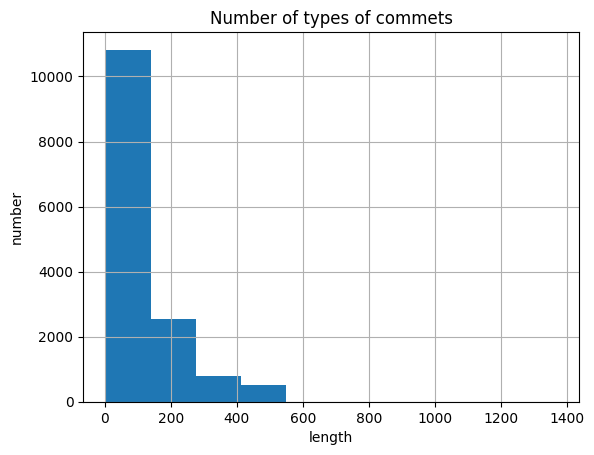

count    14660.000000
mean       109.429263
std        109.645340
min          3.000000
25%         34.000000
50%         71.000000
75%        144.000000
max       1368.000000
dtype: float64


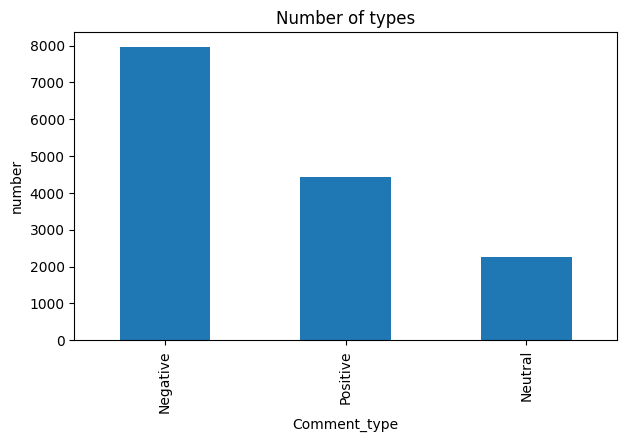

In [ ]:
eda = EDA()
eda.get_length_dist(df['content'])
eda.get_class_dist(df)

#### Preprocess the data

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def preprocess_text(text):
    # Remove HTML tags and strip whitespace
    text = re.sub(r'<[^>]*>', '', text)
    text = text.strip()
    # Remove noisy characters and extra spaces
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    # Lowercase text
    text = text.lower()
    # Tokenize text and remove stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)


In [ ]:
df['content'] = df['content'].apply(preprocess_text)

In [ ]:
df['content'].head(20)

,content
0,works correctly ok rare garbage continuously c...
1,keeps freezing please fix
2,useful tool
3,app getting closed repeatedly telling app bug ...
4,please make animation screen walpaper okk
5,love ewatch
6,crashes manually refreshing app watch synch
7,unable get device link samsung phone direction...
8,get setup connect
9,awesome love


#### Split x=feature, y=target

In [ ]:
x = df['content']
y = df['sentiment_rating']

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
Y = label_encode.fit_transform(df['sentiment_rating'])
Y

array([0, 0, 2, ..., 1, 0, 2])

In [ ]:
y

,sentiment_rating
0,Negative
1,Negative
2,Positive
3,Negative
4,Positive
...,...
14655,Negative
14656,Negative
14657,Neutral
14658,Negative


### Note: 0 represent negative comments and 1 represent positive comments

### Split the dataset into training and testing sets


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42)

### Create a vocabulary

In [ ]:
# Create a vocabulary
from collections import Counter
word_counts = Counter(' '.join(xtrain).split())

### Display each word in the vocabulary along with its count


In [ ]:
for word, count in word_counts.items():
    print(f"{word}: {count}")

app: 6035
keeps: 763
crashing: 447
phone: 1555
saying: 101
bug: 133
normally: 9
works: 665
okay: 72
disconnecting: 95
watch: 5351
makes: 97
vibrate: 20
happens: 32
night: 94
wakes: 5
fixed: 111
improve: 52
rating: 44
find: 309
autostart: 47
settings: 248
reset: 104
clock: 113
current: 32
time: 1361
problem: 297
still: 416
sleep: 906
detected: 25
watchs: 15
face: 496
diverse: 2
execellent: 1
easy: 359
use: 825
great: 913
tracking: 140
happy: 138
working: 738
fine: 271
even: 715
indoors: 1
strong: 5
wifi: 21
signal: 15
sucks: 112
please: 746
upgradeupdate: 1
pausing: 5
sports: 51
stopping: 43
start: 166
sync: 744
keep: 293
losing: 22
data: 409
recording: 77
done: 107
bad: 274
frustrating: 139
none: 41
dial: 270
faces: 637
says: 280
syncing: 207
forever: 11
fails: 32
work: 1062
making: 46
impossible: 46
customise: 11
neede: 1
dissatisfied: 6
poor: 138
quality: 60
absolutely: 70
awful: 56
battery: 283
life: 80
terrible: 131
notify: 19
smss: 1
accurately: 49
track: 223
anything: 171
either:

In [ ]:
vocab = [word for word, count in word_counts.most_common()]
vocab

['app',
 'watch',
 'phone',
 'time',
 'good',
 'update',
 'get',
 'work',
 'great',
 'sleep',
 'like',
 'use',
 'keeps',
 'please',
 'sync',
 'working',
 'even',
 'connect',
 'works',
 'weather',
 'steps',
 'faces',
 'would',
 'set',
 'change',
 'need',
 'fix',
 'face',
 'love',
 'smart',
 'also',
 'crashing',
 'add',
 'bluetooth',
 'one',
 'well',
 'still',
 'data',
 'fit',
 'blood',
 'really',
 'new',
 'crashes',
 'apps',
 'could',
 'everything',
 'easy',
 'pressure',
 'contacts',
 'way',
 'accurate',
 'always',
 'every',
 'heart',
 'device',
 'back',
 'option',
 'much',
 'find',
 'useless',
 'notifications',
 'problem',
 'nice',
 'keep',
 'got',
 'rate',
 'day',
 'see',
 'battery',
 'says',
 'go',
 'since',
 'bad',
 'messages',
 'using',
 'fine',
 'issue',
 'dial',
 'needs',
 'help',
 'give',
 'many',
 '2',
 'last',
 'far',
 'tried',
 'want',
 'ok',
 'times',
 'settings',
 'screen',
 'able',
 'worked',
 'open',
 'nothing',
 'better',
 'issues',
 'make',
 'show',
 'google',
 'know',


### Classification with various classifiers
#### 1. Linear SVM
#### 2. Logistic Regression (LR)
#### 3. Naive Bayes
#### 4. XGBoost
#### 5. Random Forest

In [ ]:
#Import libraries
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

#### Initialize classifiers

In [ ]:
svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0)

In [ ]:
def evaluate_model(model, xtest, ytest):
    # Make predictions using the model
    y_pred = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, y_pred)
    # Calculate precision
    precision = precision_score(ytest, y_pred)
    # Calculate recall
    recall = recall_score(ytest, y_pred)
    # Calculate f1 score
    f1 = f1_score(ytest, y_pred)
    # Generate a classification report and confusion matrix
    report = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm


In [ ]:
# Define batch size
batch_size = 1000

## 1. TF-IDF

#### TF-IDF Vectorization


In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

##### Process the data in smaller batches for training data


In [ ]:
start = timer()
tfidf_vectorizer_xtrain = []
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_tfidf = tfidf_vectorizer.fit_transform(batch_X_train)
    tfidf_vectorizer_xtrain.extend(batch_X_train_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start)

Required time for embedding TFIDF with train data:-  0.4163491070000873


##### Repeat the same process for test data


In [ ]:
start = timer()
tfidf_vectorizer_xtest = []
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_tfidf = tfidf_vectorizer.transform(batch_X_test)
    tfidf_vectorizer_xtest.extend(batch_X_test_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start)

Required time for embedding TFIDF with train data:-  0.12497279800004435


#### Fit classifiers

In [ ]:
start = timer()
# Fit the TfidfVectorizer on the entire training data
tfidf_vectorizer_xtrain = tfidf_vectorizer.fit_transform(xtrain)
print('Required time for embedding TFIDF with train data:- ', timer() - start)

start = timer()
# Transform the test data using the fitted vectorizer
tfidf_vectorizer_xtest = tfidf_vectorizer.transform(xtest)
print('Required time for embedding TFIDF with test data:- ', timer() - start)

# Convert the sparse matrices to dense arrays
tfidf_vectorizer_xtrain = tfidf_vectorizer_xtrain.toarray()
tfidf_vectorizer_xtest = tfidf_vectorizer_xtest.toarray()

# Fit the SVM classifier to the TF-IDF training data
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain) # This line is added

Required time for embedding TFIDF with train data:-  0.4301846470000328
Required time for embedding TFIDF with test data:-  0.180711982000048


#### Make predictions

### Linear SVM

In [ ]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for SVM prediction:- ', timer() - start)

Required time for SVM prediction:-  0.2627911239999321


#### Print actual vs. predicted results for LinearSVM

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 2, SVM Predicted: 2

Actual: 1, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 0, SVM Predicted: 0

Actual: 1, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 1, SVM Predicted: 0

Actual: 2, SVM Predicted: 0

Actual: 0, SVM Predicted: 0



In [ ]:
print(f"LinearSVM Accuracy: {accuracy_svm:.2f}")
print(f"LinearSVM Precision: {precision_svm:.2f}")
print(f"LinearSVM Recall: {recall_svm:.2f}")
print(f"LinearSVM F1 score: {f1_svm:.2f}")
print("Classification Report:")
print(report_svm)
print("Confusion Matrix")
print(confusion_matrix_svm)

LinearSVM Accuracy: 0.72
LinearSVM Precision: 0.69
LinearSVM Recall: 0.72
LinearSVM F1 score: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1649
           1       0.35      0.17      0.23       451
           2       0.71      0.73      0.72       832

    accuracy                           0.72      2932
   macro avg       0.61      0.59      0.59      2932
weighted avg       0.69      0.72      0.70      2932

Confusion Matrix
[[1419   95  135]
 [ 263   78  110]
 [ 176   50  606]]


### Logistic Regression

In [ ]:
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain)

In [ ]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction:- ', timer() - start)

Required time for Logistic Regression prediction:-  0.11151186999995844


#### Print actual vs. predicted results for Logistic Regression


In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 2, Logistic Regression Predicted: 2

Actual: 1, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0

Actual: 1, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 1, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0



In [ ]:
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1 score: {f1_lr:.2f}")
print("Classification Report:")
print(report_lr)
print("Confusion Matrix")
print(cm_lr)

Logistic Regression Accuracy: 0.74
Logistic Regression Precision: 0.71
Logistic Regression Recall: 0.74
Logistic Regression F1 score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83      1649
           1       0.45      0.14      0.22       451
           2       0.75      0.73      0.74       832

    accuracy                           0.74      2932
   macro avg       0.65      0.60      0.60      2932
weighted avg       0.71      0.74      0.71      2932

Confusion Matrix
[[1502   47  100]
 [ 288   65   98]
 [ 188   34  610]]


### Naive bayes

In [ ]:
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [ ]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction:- ', timer() - start)

Required time for Naive Bayes prediction:-  0.1455172500000117


#### Print actual vs. predicted results for Naive bayes


In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive bayes Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 1, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 0, Naive bayes Predicted: 0

Actual: 1, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 1, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0



In [ ]:
print(f"Naive bayes Accuracy: {accuracy_nb:.2f}")
print(f"Naive bayes Precision: {precision_nb:.2f}")
print(f"Naive bayes Recall: {recall_nb:.2f}")
print(f"Naive bayes F1 score: {f1_nb:.2f}")
print("Classification Report:")
print(report_nb)
print("Confusion Matrix:")
print(cm_nb)

Naive bayes Accuracy: 0.73
Naive bayes Precision: 0.75
Naive bayes Recall: 0.73
Naive bayes F1 score: 0.67
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.96      0.81      1649
           1       0.83      0.01      0.02       451
           2       0.79      0.66      0.72       832

    accuracy                           0.73      2932
   macro avg       0.78      0.54      0.52      2932
weighted avg       0.75      0.73      0.67      2932

Confusion Matrix:
[[1577    1   71]
 [ 367    5   79]
 [ 280    0  552]]


### XGBoost Classifier

In [ ]:
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [ ]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction:- ', timer() - start)

Required time for XGBoost classifier prediction:-  0.15228639599990856


#### Print actual vs. predicted results for XGBoost classifier


In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 2, XGBoost Predicted: 2

Actual: 1, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 0, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0



In [ ]:
print(f"XGBoost Accuracy: {accuracy_xgboost:.2f}")
print(f"XGBoost Precision: {precision_xgboost:.2f}")
print(f"XGBoost Recall: {recall_xgboost:.2f}")
print(f"XGBoost F1 score: {f1_xgboost:.2f}")
print("Classification Report:")
print(report_xgboost)
print("Confusion Matrix:")
print(cm_xgboost)

XGBoost Accuracy: 0.72
XGBoost Precision: 0.69
XGBoost Recall: 0.72
XGBoost F1 score: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81      1649
           1       0.47      0.14      0.21       451
           2       0.75      0.65      0.70       832

    accuracy                           0.72      2932
   macro avg       0.65      0.57      0.57      2932
weighted avg       0.69      0.72      0.69      2932

Confusion Matrix:
[[1508   37  104]
 [ 308   61   82]
 [ 256   32  544]]


### Random Forest Classifier

In [ ]:
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [ ]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction:- ', timer() - start)

Required time for Random Forest classifier prediction:-  0.12682218300005843


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

#### Print actual vs. predicted results for Random Forest classifier

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 1, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 1, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 1, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0



In [ ]:
print(f"Random Forest Accuracy: {accuracy_rfc:.2f}")
print(f"Random Forest Precision: {precision_rfc:.2f}")
print(f"Random Forest Recall: {recall_rfc:.2f}")
print(f"Random Forest F1 score: {f1_rfc:.2f}")
print("Classification Report:")
print(report_rfc)
print("Confusion Matrix:")
print(cm_rfc)

Random Forest Accuracy: 0.56
Random Forest Precision: 0.32
Random Forest Recall: 0.56
Random Forest F1 score: 0.40
Classification Report:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72      1649
           1       0.00      0.00      0.00       451
           2       0.00      0.00      0.00       832

    accuracy                           0.56      2932
   macro avg       0.19      0.33      0.24      2932
weighted avg       0.32      0.56      0.40      2932

Confusion Matrix:
[[1649    0    0]
 [ 451    0    0]
 [ 832    0    0]]


#### Display all five models accuracy

In [ ]:
model_names = ['LinearSVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

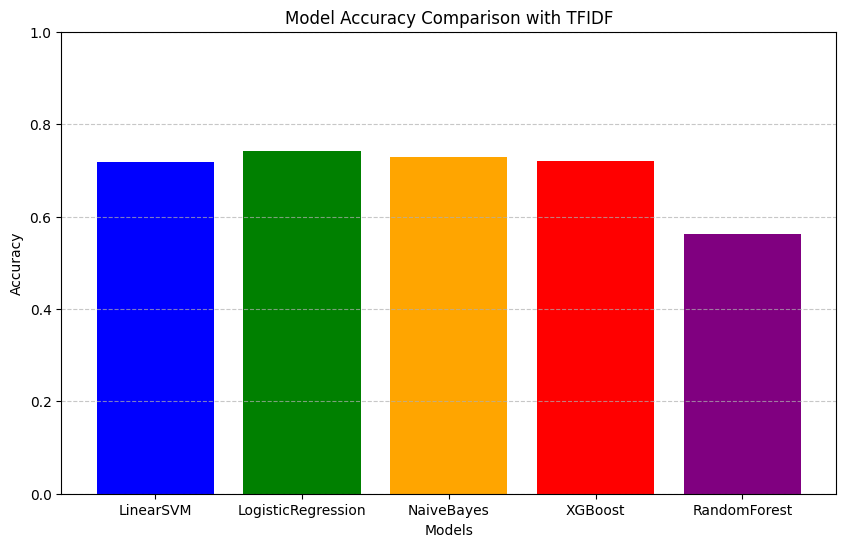

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with TFIDF")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 2. Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

#### Load the Universal Sentence Encoder model, and embed this model

In [ ]:
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for upload USE from tensorflow hub:- ', timer() - start)

Required time for upload USE from tensorflow hub:-  22.67405314100006


In [ ]:
xtrain_use = []
xtest_use = []

In [ ]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_use = np.array(embed(batch_X_train))
    xtrain_use.extend(batch_X_train_use)
print('Required time for embedding xtrain with USE:- ', timer() - start)

Required time for embedding xtrain with USE:-  3.4235757500000545


In [ ]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_use = np.array(embed(batch_X_test))
    xtest_use.extend(batch_X_test_use)
print('Required time for embedding xtest with USE:- ', timer() - start)

Required time for embedding xtest with USE:-  0.6556886460000442


#### Fit classifiers

In [ ]:
start = timer()
svm_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier:- ', timer() - start)
start = timer()
lr_use = logistic_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_use = xgboost_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training all Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM classifier:-  8.728166426999906
Required time for training Logistic Regression:-  4.078456834000008
Required time for training XGBoost classifier:-  69.39281943299989
Required time for training all Random Forest classifier:-  6.472764289999986


#### Make predictions

### Linear SVM

In [ ]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start)

Required time for Linear SVM prediction with USE :-  0.035156215999904816


#### Print actual vs. predicted results for LinearSVM with USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 1, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 1, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 1, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0



In [ ]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("Classification Report:")
print(report_svm_use)
print("Confusion Matrix")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.72
LinearSVM (USE) Precision: 0.68
LinearSVM (USE) Recall: 0.72
LinearSVM (USE) F1 score: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81      1649
           1       0.41      0.07      0.12       451
           2       0.69      0.74      0.71       832

    accuracy                           0.72      2932
   macro avg       0.62      0.57      0.55      2932
weighted avg       0.68      0.72      0.68      2932

Confusion Matrix
[[1469   25  155]
 [ 295   32  124]
 [ 195   21  616]]


### Logitic Regression

In [ ]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_use, xtest_use, ytest)
print('Required time for LR prediction with USE :- ', timer() - start)

Required time for LR prediction with USE :-  0.03438476599990281


#### Print actual vs. predicted results for Logistic Regression with USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted with USE: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 1, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 1, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 1, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0



In [ ]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("Classification Report:")
print(report_lr_use)
print("Confusion Matrix")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.72
Logistic Regression (USE) Precision: 0.68
Logistic Regression (USE) Recall: 0.72
Logistic Regression (USE) F1 score: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81      1649
           1       0.37      0.10      0.15       451
           2       0.71      0.72      0.72       832

    accuracy                           0.72      2932
   macro avg       0.61      0.57      0.56      2932
weighted avg       0.68      0.72      0.68      2932

Confusion Matrix
[[1475   41  133]
 [ 297   43  111]
 [ 200   32  600]]


### XGBoost Classifier

In [ ]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start)

Required time for XGBoost classifier prediction with USE:-  0.056700934999980745


#### Print actual vs. predicted results for XGBooost classifier with USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 2

Actual: 1, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 0

Actual: 1, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 1, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0



In [ ]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("Classification Report:")
print(report_xgboost_use)
print("Confusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.72
XGBoost (USE) Precision: 0.67
XGBoost (USE) Recall: 0.72
XGBoost (USE) F1 score: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81      1649
           1       0.33      0.10      0.16       451
           2       0.73      0.69      0.71       832

    accuracy                           0.72      2932
   macro avg       0.60      0.56      0.56      2932
weighted avg       0.67      0.72      0.68      2932

Confusion Matrix:
[[1482   45  122]
 [ 314   46   91]
 [ 210   48  574]]


### Random Forest Classifier

In [ ]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_use, xtest_use, ytest)
print('Required time for Random Forest classifier with USE prediction:- ', timer() - start)

Required time for Random Forest classifier with USE prediction:-  0.06794435199981308


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

#### Print actual vs. predicted results for Random Forest classifier with USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 1, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 0, Random Forest with USE Predicted: 0

Actual: 1, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 1, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0



In [ ]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("Classification Report:")
print(report_rfc_use)
print("Confusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.68
Random Forest (USE) Precision: 0.62
Random Forest (USE) Recall: 0.68
Random Forest (USE) F1 score: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.98      0.78      1649
           1       0.00      0.00      0.00       451
           2       0.89      0.45      0.60       832

    accuracy                           0.68      2932
   macro avg       0.51      0.48      0.46      2932
weighted avg       0.62      0.68      0.61      2932

Confusion Matrix:
[[1622    0   27]
 [ 431    0   20]
 [ 454    0  378]]


#### Display all four models accuracy
##### (--Note: Naive bayes (MultinomialNB) model not used with USE embedding because it not able to resolve the issue of negative values)

In [ ]:
model_names = ['LinearSVM', 'LogisticRegression', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

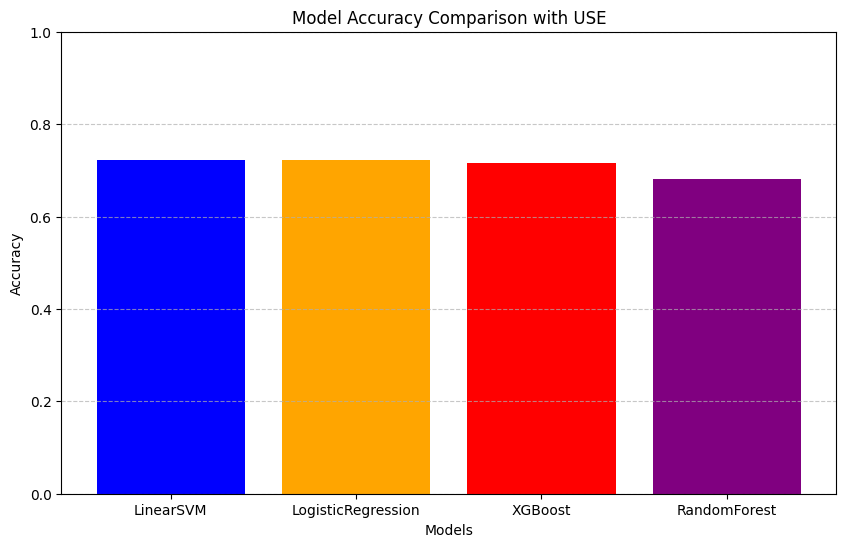

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with USE")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 3. TF-IDF + Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

#### Combine TF-IDF and Universal Sentence Encoder embeddings


In [ ]:
xtrain_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtrain, xtrain_use], axis=1)
xtest_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtest, xtest_use], axis=1)

#### Fit classifiers

In [ ]:
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM:- ', timer() - start)
start = timer()
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM:-  11.985906375000013
Required time for training Logistic Regression:-  31.512998745999994
Required time for training XGBoost classifier:-  217.32013909700004
Required time for training Random Forest classifier:-  5.840892057000019


#### Make predictions

### Linear SVM

In [ ]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TFIDF+USE :- ', timer() - start)

Required time for Linear SVM prediction with TFIDF+USE :-  0.0752086910001708


#### Print actual vs. predicted results for Linear SVM with TFIDF + USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, SVM with TFIDF+USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 1, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 1, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 1, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0



In [ ]:
print(f"LinearSVM (TFIDF+USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix")
print(cm_svm_tfidf_use)

LinearSVM (TFIDF+USE) Accuracy: 0.72
LinearSVM (TFIDF+USE) Precision: 0.69
LinearSVM (TFIDF+USE) Recall: 0.72
LinearSVM (TFIDF+USE) F1 score: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81      1649
           1       0.34      0.20      0.25       451
           2       0.71      0.74      0.73       832

    accuracy                           0.72      2932
   macro avg       0.61      0.60      0.60      2932
weighted avg       0.69      0.72      0.70      2932

Confusion Matrix
[[1406  111  132]
 [ 249   88  114]
 [ 155   60  617]]


### Logistic Regression

In [ ]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TFIDF+USE :- ', timer() - start)

Required time for Logistic Regression prediction with TFIDF+USE :-  0.06601013099998454


#### Print actual vs. predicted results for Logistic Regression with TFIDF + USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Actual: {actual}, LR with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 1, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 1, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 1, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0



In [ ]:
print(f"Logistic Regression (TFIDF+USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix")
print(cm_lr_tfidf_use)

Logistic Regression (TFIDF+USE) Accuracy: 0.74
Logistic Regression (TFIDF+USE) Precision: 0.71
Logistic Regression (TFIDF+USE) Recall: 0.74
Logistic Regression (TFIDF+USE) F1 score: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83      1649
           1       0.41      0.19      0.26       451
           2       0.74      0.75      0.75       832

    accuracy                           0.74      2932
   macro avg       0.64      0.61      0.61      2932
weighted avg       0.71      0.74      0.72      2932

Confusion Matrix
[[1468   70  111]
 [ 260   86  105]
 [ 156   53  623]]


### XGBoost Classifier

In [ ]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TFIDF+USE :- ', timer() - start)

Required time for XGBoost prediction with TFIDF+USE :-  0.3483459439999024


#### Print actual vs. predicted results for XGBoost with TFIDF + USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Actual: {actual}, XGBoost with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0



In [ ]:
print(f"XGBoost (TFIDF+USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TFIDF+USE) Accuracy: 0.72
XGBoost (TFIDF+USE) Precision: 0.68
XGBoost (TFIDF+USE) Recall: 0.72
XGBoost (TFIDF+USE) F1 score: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      1649
           1       0.37      0.12      0.18       451
           2       0.73      0.71      0.72       832

    accuracy                           0.72      2932
   macro avg       0.62      0.57      0.57      2932
weighted avg       0.68      0.72      0.69      2932

Confusion Matrix:
[[1482   47  120]
 [ 304   52   95]
 [ 200   41  591]]


### Random Forest classifier

In [ ]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TFIDF+USE :- ', timer() - start)

Required time for Random Forest prediction with TFIDF+USE :-  0.08844600099973832


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

#### Print actual vs. predicted results for Random Forest with TFIDF + USE

In [ ]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_tfidf_use[:15]):
    print(f"Actual: {actual}, RFC with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 1, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 1, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 1, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0



In [ ]:
print(f"Random Forest (TFIDF+USE) Accuracy: {accuracy_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Precision: {precision_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Recall: {recall_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) F1 score: {f1_rfc_tfidf_use:.2f}")
print("Classification Report:")
print(report_rfc_tfidf_use)
print("Confusion Matrix:")
print(cm_rfc_tfidf_use)

Random Forest (TFIDF+USE) Accuracy: 0.65
Random Forest (TFIDF+USE) Precision: 0.61
Random Forest (TFIDF+USE) Recall: 0.65
Random Forest (TFIDF+USE) F1 score: 0.56
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.99      0.76      1649
           1       0.00      0.00      0.00       451
           2       0.91      0.32      0.48       832

    accuracy                           0.65      2932
   macro avg       0.51      0.44      0.41      2932
weighted avg       0.61      0.65      0.56      2932

Confusion Matrix:
[[1634    0   15]
 [ 439    0   12]
 [ 563    0  269]]


### Visualization

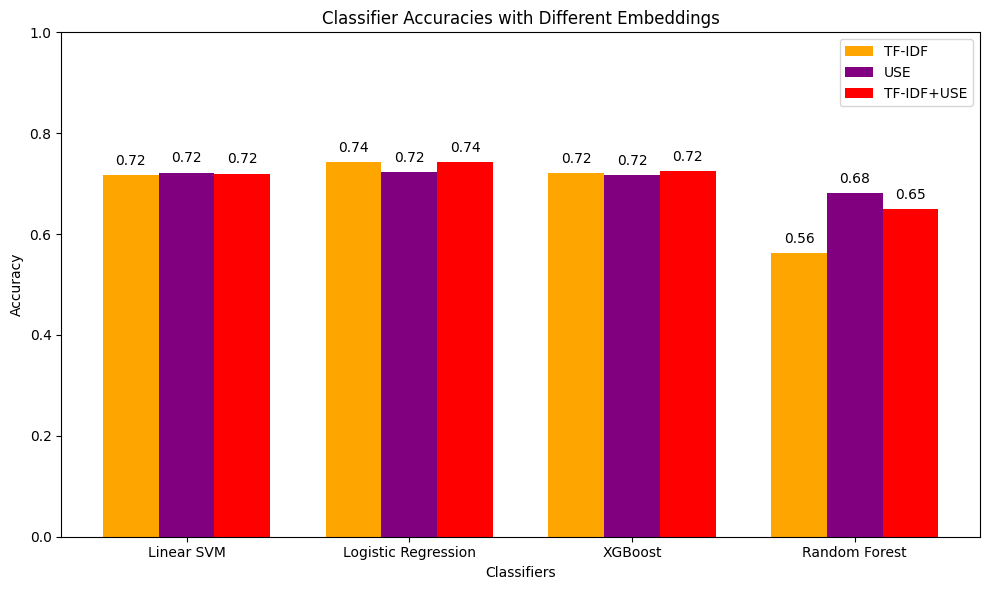

In [ ]:
# Define the classifiers and their corresponding accuracies
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]  # Replace with actual accuracy values
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]  # Replace with actual accuracy values
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]  # Replace with actual accuracy values

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')


# Display the plot
plt.tight_layout()
plt.show()


#### Conclusion: If you see above visualization, as compared to TF-IDF embedding, USE as well as TF-IDF+USE embeddings works better for sentiment analysis on IMDB dataset with different classifiers

Reference:
https://github.com/FarhanaTeli/Sentiment_Analysis_IMDB

https://github.com/Wittline/tf-idf

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
import scipy.sparse as sp
from numpy.linalg import norm

class TFIDF(object):

    def __init__(self, corpus):
        self.corpus = corpus
        self.norm_corpus  = None

    def __normalize_corpus(self, d):
        stop_words = nltk.corpus.stopwords.words('english')
        d = re.sub(r'[^a-zA-Z0-9\s]', '', d, re.I|re.A)
        d = d.lower().strip()
        tks = nltk.word_tokenize(d)
        f_tks = [t for t in tks if t not in stop_words]
        return ' '.join(f_tks)

    def preprocessing_text(self):
        n_c = np.vectorize(self.__normalize_corpus)
        self.norm_corpus = n_c(self.corpus)

    def tf(self):
        words_array = [doc.split() for doc in self.norm_corpus]
        words = list(set([word for words in words_array for word in words]))
        features_dict = {w:0 for w in words}
        tf = []
        for doc in self.norm_corpus:
            bowf_doc = Counter(doc.split())
            all_f = Counter(features_dict)
            bowf_doc.update(all_f)
            tf.append(bowf_doc)
        return pd.DataFrame(tf)

    def df(self, tf):
        features_names = list(tf.columns)
        df = np.diff(sp.csc_matrix(tf, copy=True).indptr)
        df = 1 + df
        return df

    def idf(self, df):
        N = 1 + len(self.norm_corpus)
        idf = (1.0 + np.log(float(N) / df))
        idf_d = sp.spdiags(idf, diags= 0, m=len(df), n= len(df)).todense()
        return idf, idf_d

    def tfidf(self, tf, idf):
        tf = np.array(tf, dtype='float64')
        tfidf = tf * idf
        norms = norm(tfidf , axis=1)
        return (tfidf / norms[:,None])